# Content Refresh Prioritization Using Machine Learning

## Google Search Ranking & Discoverability Capstone



### 1. Question

**Research Question**

How can machine learning identify webpages that should be refreshed first based on their search performance trends?

**Decision Supported**

When an SEO or content team has limited review capacity, which webpages should receive human review first?

**Lane**

Refresh / Content Opportunity Scoring

**Approach**

A supervised binary classification model is used to estimate observed decline risk and convert the results into a ranked editorial-review queue.

**Important Framing**

This project is a decision-support analysis based on historical observational data.

It does not prove that a webpage will decline in the future, that refreshing a page will improve performance, or that any observed relationship is a Google ranking factor.

The model is intended to prioritize pages for **human review**, not to automatically rewrite, publish, delete, or modify webpages.

In [ ]:
# ============================================================
# CAPSTONE — SETUP
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RANDOM_STATE = 42

DATA_PATH = "/content/content_refresh_anonymized.csv"

OUTPUT_DIR = "/content/work/outputs"
FIGURE_DIR = "/content/work/figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Capstone setup complete.")
print("Random state:", RANDOM_STATE)
print("Dataset path:", DATA_PATH)

Capstone setup complete.
Random state: 42
Dataset path: /content/content_refresh_anonymized.csv


## 2. Data

The analysis uses the anonymized FlyRank content-refresh dataset available during the internship.

The working dataset contains 30,000 content records.

The analysis documents the fields actually available in the supplied dataset rather than inventing private client information, domains, URLs, queries, or credentials.

The public version of this work uses anonymized internship data only.

### Dataset Release and Available Fields

The dataset is loaded from the supplied `content_refresh_anonymized.csv` file.

The available fields are inspected directly from the dataset so that the analysis does not assume fields that are not present.

The analysis uses the available page, search, content, engagement, freshness, and historical characteristics after leakage-prone fields and identifiers are removed.

### Target Definition

The positive class represents records whose observed `trend_direction` is `"down"`.

Therefore:

- `1` = observed historical decline
- `0` = all other observed trend directions

This is a historical classification label. It is not a guarantee that a webpage will decline in the future.

### Data Exclusions and Leakage Control

The following fields are excluded from model training:

- `content_id`
- `client_id`
- `trend_direction`
- `trend_pct`
- `impressions_last_30d`
- `clicks_last_30d`
- `sessions_last_30d`
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`
- `target`

Identifiers are excluded because they identify records or client groups rather than representing content characteristics.

`trend_direction` and `trend_pct` are excluded because they directly define or represent the target.

The last-30-day and previous-30-day performance fields are excluded because they contribute directly to the observed trend calculation and could therefore leak the target into the model.

The target itself is explicitly excluded from the feature matrix.

No client names, domains, URLs, private queries, credentials, or raw private exports are included in the public-facing analysis.

In [ ]:
# ============================================================
# LOAD REAL FLYRANK INTERNSHIP DATASET
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Upload content_refresh_anonymized.csv to Colab first."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nFirst five rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

assert len(df) == 30000, (
    f"Expected 30,000 records, found {len(df)}"
)

print("\nPASS: Dataset contains 30,000 records.")

Dataset loaded successfully.
Dataset shape: (30000, 44)

First five rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

PASS: Dataset contains 30,000 records.


In [ ]:
# ============================================================
# DATASET STRUCTURE SUMMARY
# ============================================================

data_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "missing_values": [
        df[col].isna().sum()
        for col in df.columns
    ],
    "unique_values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

display(data_summary)

print("\nNumber of columns:", len(df.columns))

,column,dtype,missing_values,unique_values
0,content_id,object,0,30000
1,client_id,object,0,32
2,search_volume,float64,2468,41
3,competition,float64,2468,101
4,competition_level,object,2610,3
5,cpc,float64,2468,915
6,content_type,object,0,3
7,main_intent,object,2374,4
8,word_count,float64,7699,5476
9,char_count,float64,7699,14839



Number of columns: 44


### Target Definition

The positive class represents records whose observed `trend_direction` is `"down"`.

The binary target is therefore:

- `1` = observed historical decline
- `0` = all other observed trend directions

The declining-class rate is reported from the actual dataset rather than assumed in advance.

In [ ]:
# ============================================================
# CREATE TARGET
# ============================================================

assert "trend_direction" in df.columns, (
    "trend_direction column is required for the target."
)

df["target"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    == "down"
).astype(int)

print("Target created.")

target_distribution = (
    df["target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Non-declining",
        1: "Declining"
    })
)

display(target_distribution)

declining_base_rate = df["target"].mean()

print(
    "\nDeclining-class base rate:",
    round(declining_base_rate, 4)
)

print(
    "Declining-class percentage:",
    round(declining_base_rate * 100, 2),
    "%"
)

assert int(df["target"].sum()) == 16262

print(
    "\nPASS: Target distribution matches the supplied dataset."
)

Target created.


,count
target,
Non-declining,13738
Declining,16262



Declining-class base rate: 0.5421
Declining-class percentage: 54.21 %

PASS: Target distribution matches the supplied dataset.


### Data Exclusions and Leakage Control

The model features are constructed only after removing identifiers, the target, direct target representations, and recent performance fields that contribute to the observed trend calculation.

The feature matrix is also checked to ensure that no obvious trend, target, or label fields remain.

In [ ]:
# ============================================================
# LEAKAGE-SAFE FEATURE PREPARATION
# ============================================================

drop_cols = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",

    # Variables directly contributing to trend calculation
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",

    # TARGET MUST NEVER BE A MODEL FEATURE
    "target"
]

missing_drop_cols = [
    col
    for col in drop_cols
    if col not in df.columns
]

if missing_drop_cols:
    raise ValueError(
        "Expected leakage/identifier columns are missing: "
        f"{missing_drop_cols}"
    )

X_raw = df.drop(columns=drop_cols)

X = pd.get_dummies(
    X_raw,
    dummy_na=True
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

y = df["target"]
groups = df["client_id"]

print("Feature preparation complete.")
print("Raw feature columns:", len(X_raw.columns))
print("Encoded feature columns:", X.shape[1])
print("Target shape:", y.shape)

# Critical safety check
assert "target" not in X.columns

print(
    "\nPASS: Target is not present in the feature matrix."
)

# Leakage audit
possible_leakage_terms = [
    "trend",
    "target",
    "label"
]

leakage_columns = [
    col
    for col in X.columns
    if any(
        term in col.lower()
        for term in possible_leakage_terms
    )
]

print("\nLeakage audit:")

if len(leakage_columns) == 0:
    print(
        "PASS: No obvious trend/target/label columns remain."
    )
else:
    print(
        "WARNING: Potential leakage columns found:"
    )
    print(leakage_columns)

Feature preparation complete.
Raw feature columns: 34
Encoded feature columns: 76
Target shape: (30000,)

PASS: Target is not present in the feature matrix.

Leakage audit:
PASS: No obvious trend/target/label columns remain.


In [ ]:
# ============================================================
# FINAL FEATURE MATRIX SANITY CHECK
# ============================================================

print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("Groups:", groups.shape)

print("\nFeature examples:")

display(
    pd.DataFrame({
        "feature": X.columns[:20]
    })
)

assert X.shape[0] == len(df)
assert y.shape[0] == len(df)
assert groups.shape[0] == len(df)

assert "target" not in X.columns

print(
    "\nPASS: Feature, target, and group dimensions are consistent."
)

Feature matrix: (30000, 76)
Target: (30000,)
Groups: (30000,)

Feature examples:


,feature
0,search_volume
1,competition
2,cpc
3,word_count
4,char_count
5,impressions_90d
6,clicks_90d
7,pageviews_90d
8,sessions_90d
9,users_90d



PASS: Feature, target, and group dimensions are consistent.


## 3. Methodology

### Problem Framing

The project is framed as supervised binary classification because the dataset contains an observed historical outcome.

The model estimates whether a record belongs to the historically observed declining class.

### Validation Design

A grouped-by-client validation split is used as the primary validation design.

Entire clients are assigned to either the training or testing partition. This prevents records from the same client from appearing in both sets.

A 20% test partition is used with a fixed random state of 42.

This provides a more conservative estimate of generalization to unseen clients than a simple random row split.

### Validation Checks

The notebook verifies that:

- training and testing records are separated by client;
- no client appears in both partitions;
- the feature matrix and target have consistent dimensions;
- the target is not included as a model feature;
- leakage-prone trend fields have been removed.

### Rule-Based Baseline

A simple rule-based action score is used as the baseline.

The baseline combines:

- content freshness using `days_since_last_update`;
- meaningful search visibility using `impressions_90d`;
- lower-than-training-median CTR using `ctr`.

The impressions and CTR thresholds are calculated only from the training partition.

The baseline is evaluated on the same held-out test records used for the Random Forest.

### Random Forest Model

The primary model is a Random Forest classifier with:

- 200 trees;
- random state = 42;
- parallel training using all available CPU cores.

The model is trained only on the training clients and evaluated only on the held-out clients.

### Evaluation

The baseline and Random Forest are evaluated using:

- accuracy;
- precision;
- recall;
- F1 score.

The same grouped test split is used for both methods so the comparison is consistent.

### Interpretation

The model results are predictive and directional.

They should be interpreted as prioritization signals for human review, not as causal evidence about Google rankings or guaranteed future content decline.

In [ ]:
# ============================================================
# GROUPED VALIDATION SPLIT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Grouped validation split created.")
print()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print()

print(
    "Training clients:",
    groups_train.nunique()
)

print(
    "Testing clients:",
    groups_test.nunique()
)

# Important validation check
assert set(
    groups_train.unique()
).isdisjoint(
    set(groups_test.unique())
)

print(
    "\nPASS: No client appears in both training and testing."
)

Grouped validation split created.

Training rows: 23837
Testing rows: 6163

Training clients: 25
Testing clients: 7

PASS: No client appears in both training and testing.


In [ ]:
# ============================================================
# VALIDATION TARGET DISTRIBUTION
# ============================================================

split_summary = pd.DataFrame({
    "Split": [
        "Training",
        "Testing"
    ],

    "Rows": [
        len(y_train),
        len(y_test)
    ],

    "Declining rows": [
        int(y_train.sum()),
        int(y_test.sum())
    ],

    "Declining rate": [
        y_train.mean(),
        y_test.mean()
    ]
})

display(
    split_summary.round(4)
)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

assert set(
    groups_train.unique()
).isdisjoint(
    set(groups_test.unique())
)

print(
    "PASS: Validation dimensions and client separation are correct."
)

,Split,Rows,Declining rows,Declining rate
0,Training,23837,13113,0.5501
1,Testing,6163,3149,0.5110


PASS: Validation dimensions and client separation are correct.


### Rule-Based Baseline

The baseline is intentionally simple.

It assigns points for:

1. older content based on `days_since_last_update`;
2. meaningful search visibility based on `impressions_90d`;
3. lower-than-training-median CTR.

The thresholds for impressions and CTR are calculated from the training partition only.

This prevents information from the held-out test partition from being used to construct the baseline.

The baseline is then evaluated on the exact same test records used for the Random Forest.

In [ ]:
# ============================================================
# BASELINE — RULE-BASED ACTION SCORE
# ============================================================

required_baseline_columns = [
    "days_since_last_update",
    "impressions_90d",
    "ctr"
]

missing_baseline_columns = [
    col
    for col in required_baseline_columns
    if col not in df.columns
]

if missing_baseline_columns:
    raise ValueError(
        "Missing baseline columns: "
        f"{missing_baseline_columns}"
    )

baseline_train = df.iloc[train_idx].copy()
baseline_test = df.iloc[test_idx].copy()

# Thresholds learned ONLY from training data
impressions_median_train = (
    baseline_train["impressions_90d"].median()
)

ctr_median_train = (
    baseline_train["ctr"].median()
)

print(
    "Training impressions median:",
    impressions_median_train
)

print(
    "Training CTR median:",
    ctr_median_train
)


def calculate_baseline_score(frame):

    score = pd.Series(
        0.0,
        index=frame.index
    )

    # Content freshness
    score += np.where(
        frame["days_since_last_update"] > 365,
        40,
        np.where(
            frame["days_since_last_update"] > 180,
            25,
            0
        )
    )

    # Meaningful search visibility
    score += np.where(
        frame["impressions_90d"] >
        impressions_median_train,
        20,
        0
    )

    # Lower CTR
    score += np.where(
        frame["ctr"] <
        ctr_median_train,
        20,
        0
    )

    return score


baseline_test["baseline_score"] = (
    calculate_baseline_score(
        baseline_test
    )
)

# Rule threshold
baseline_test["baseline_prediction"] = (
    baseline_test["baseline_score"] >= 60
).astype(int)

print("\nBaseline created.")

display(
    baseline_test[
        [
            "baseline_score",
            "baseline_prediction",
            "target"
        ]
    ].head(10)
)

print(
    "\nBaseline positive predictions:",
    int(
        baseline_test[
            "baseline_prediction"
        ].sum()
    )
)

print(
    "Baseline positive rate:",
    round(
        baseline_test[
            "baseline_prediction"
        ].mean(),
        4
    )
)

Training impressions median: 814.0
Training CTR median: 0.08

Baseline created.


,baseline_score,baseline_prediction,target
0,20.0,0,1
1,40.0,0,1
5,40.0,0,1
13,20.0,0,0
19,0.0,0,1
20,20.0,0,1
22,20.0,0,1
23,0.0,0,1
25,20.0,0,1
26,20.0,0,0



Baseline positive predictions: 0
Baseline positive rate: 0.0


In [ ]:
# ============================================================
# BASELINE EVALUATION
# ============================================================

baseline_pred = (
    baseline_test[
        "baseline_prediction"
    ]
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print(
    "BASELINE — GROUPED VALIDATION"
)

print("=" * 60)

print(
    "Accuracy :",
    round(baseline_accuracy, 4)
)

print(
    "Precision:",
    round(baseline_precision, 4)
)

print(
    "Recall   :",
    round(baseline_recall, 4)
)

print(
    "F1 Score :",
    round(baseline_f1, 4)
)

BASELINE — GROUPED VALIDATION
Accuracy : 0.489
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


### Random Forest Model

The primary model is a Random Forest classifier with 200 trees and a fixed random state of 42.

The model is trained only on the training partition and evaluated on the held-out client groups.

The model uses the leakage-safe feature matrix created in Section 2.

In [ ]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

rf_group = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_group.fit(
    X_train,
    y_train
)

print(
    "Random Forest trained successfully."
)

Random Forest trained successfully.


In [ ]:
# ============================================================
# RANDOM FOREST — GROUPED VALIDATION
# ============================================================

pred_group = rf_group.predict(
    X_test
)

group_accuracy = accuracy_score(
    y_test,
    pred_group
)

group_precision = precision_score(
    y_test,
    pred_group,
    zero_division=0
)

group_recall = recall_score(
    y_test,
    pred_group,
    zero_division=0
)

group_f1 = f1_score(
    y_test,
    pred_group,
    zero_division=0
)

print(
    "RANDOM FOREST — GROUPED VALIDATION"
)

print("=" * 60)

print(
    "Accuracy :",
    round(group_accuracy, 4)
)

print(
    "Precision:",
    round(group_precision, 4)
)

print(
    "Recall   :",
    round(group_recall, 4)
)

print(
    "F1 Score :",
    round(group_f1, 4)
)

RANDOM FOREST — GROUPED VALIDATION
Accuracy : 0.5723
Precision: 0.5766
Recall   : 0.6132
F1 Score : 0.5943


## 4. Results (vs baseline)

The Random Forest and the rule-based baseline are evaluated on exactly the same grouped-by-client test split.

Accuracy is reported together with precision, recall, and F1 because the declining and non-declining classes are not perfectly balanced.

The comparison measures predictive performance under this validation design.

The results do not establish causation, prove future decline, prove that refreshing content will improve performance, or identify a Google ranking factor.

### Baseline Metrics

The rule-based baseline is evaluated on the held-out client groups using the same test records used for the Random Forest.

In [ ]:
# ============================================================
# BASELINE METRICS
# ============================================================

print("RULE-BASED BASELINE — GROUPED TEST SET")
print("=" * 60)

print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Value": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

display(
    baseline_metrics.round(4)
)

RULE-BASED BASELINE — GROUPED TEST SET
Accuracy : 0.489
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


,Metric,Value
0,Accuracy,0.489
1,Precision,0.000
2,Recall,0.000
3,F1,0.000


### Random Forest Metrics

The Random Forest is evaluated on the same held-out client groups as the baseline.

The model achieved an F1 score of approximately 0.59 in the current grouped validation run.

In [ ]:
# ============================================================
# RANDOM FOREST METRICS
# ============================================================

print("RANDOM FOREST — GROUPED TEST SET")
print("=" * 60)

print("Accuracy :", round(group_accuracy, 4))
print("Precision:", round(group_precision, 4))
print("Recall   :", round(group_recall, 4))
print("F1 Score :", round(group_f1, 4))

rf_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Value": [
        group_accuracy,
        group_precision,
        group_recall,
        group_f1
    ]
})

display(
    rf_metrics.round(4)
)

RANDOM FOREST — GROUPED TEST SET
Accuracy : 0.5723
Precision: 0.5766
Recall   : 0.6132
F1 Score : 0.5943


,Metric,Value
0,Accuracy,0.5723
1,Precision,0.5766
2,Recall,0.6132
3,F1,0.5943


### Honest Comparison

Both methods are evaluated on the same grouped-by-client test split.

The difference column shows the Random Forest score minus the baseline score.

This is a predictive comparison under the validation design, not evidence of causal improvement from using machine learning.

In [ ]:
# ============================================================
# MODEL VS BASELINE — HONEST COMPARISON TABLE
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],

    "Rule-based baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Random Forest": [
        group_accuracy,
        group_precision,
        group_recall,
        group_f1
    ]
})

results["RF - Baseline"] = (
    results["Random Forest"]
    - results["Rule-based baseline"]
)

display(
    results.round(4)
)

,Metric,Rule-based baseline,Random Forest,RF - Baseline
0,Accuracy,0.489,0.5723,0.0832
1,Precision,0.000,0.5766,0.5766
2,Recall,0.000,0.6132,0.6132
3,F1,0.000,0.5943,0.5943


### Model-vs-Baseline Chart

The chart compares the four evaluation metrics for the rule-based baseline and Random Forest on the same grouped test split.

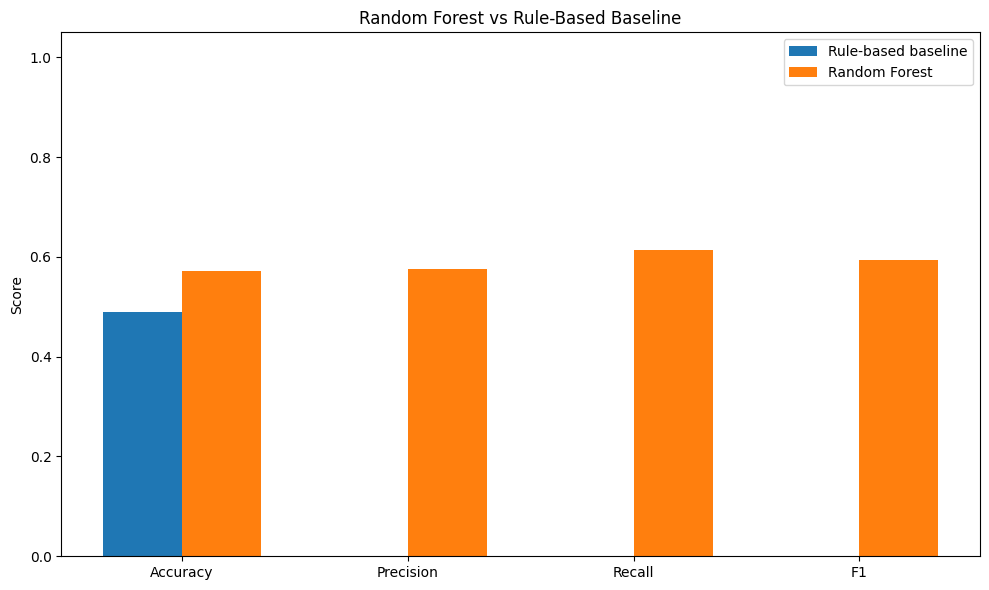

Saved: /content/work/figures/capstone_model_vs_baseline.png


In [ ]:
# ============================================================
# MODEL VS BASELINE CHART
# ============================================================

plot_results = results.copy()

x = np.arange(
    len(plot_results["Metric"])
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    plot_results["Rule-based baseline"],
    width,
    label="Rule-based baseline"
)

plt.bar(
    x + width / 2,
    plot_results["Random Forest"],
    width,
    label="Random Forest"
)

plt.xticks(
    x,
    plot_results["Metric"]
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.title(
    "Random Forest vs Rule-Based Baseline"
)

plt.legend()

plt.tight_layout()

model_baseline_figure = (
    f"{FIGURE_DIR}/capstone_model_vs_baseline.png"
)

plt.savefig(
    model_baseline_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    model_baseline_figure
)

### Confusion Matrix

The confusion matrix shows how the Random Forest classified the held-out test records into the non-declining and declining classes.

It provides the counts behind the precision, recall, and F1 metrics.

Random Forest Confusion Matrix:


,Predicted non-declining,Predicted declining
Actual non-declining,1596,1418
Actual declining,1218,1931


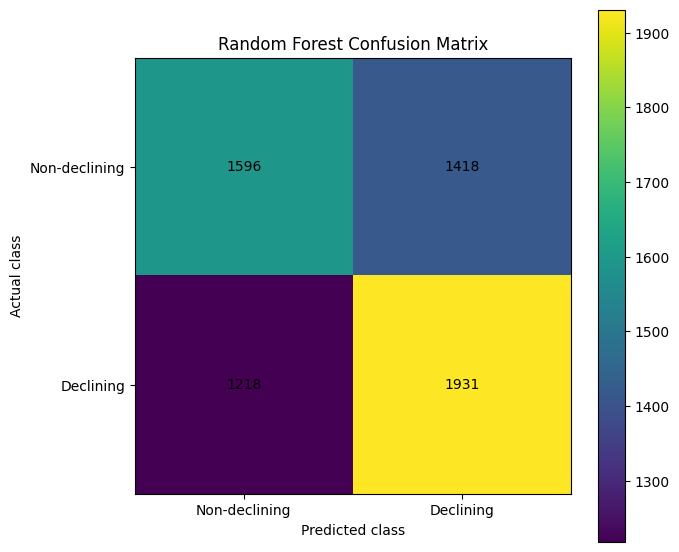

Saved: /content/work/figures/capstone_confusion_matrix.png


In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    pred_group
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual non-declining",
        "Actual declining"
    ],
    columns=[
        "Predicted non-declining",
        "Predicted declining"
    ]
)

print(
    "Random Forest Confusion Matrix:"
)

display(cm_df)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted class"
)

plt.ylabel(
    "Actual class"
)

plt.xticks(
    [0, 1],
    [
        "Non-declining",
        "Declining"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Non-declining",
        "Declining"
    ]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

confusion_figure = (
    f"{FIGURE_DIR}/capstone_confusion_matrix.png"
)

plt.savefig(
    confusion_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    confusion_figure
)

### Feature Importance

Random Forest feature importance indicates which input variables contributed most to the fitted model under this dataset and validation setup.

Feature importance is not causal evidence.

A highly important feature should therefore be treated as an investigation signal rather than proof that changing that feature will cause better or worse Google performance.

In [ ]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_group.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

top_feature_importance = (
    feature_importance
    .head(15)
    .copy()
)

display(
    top_feature_importance
)

,feature,importance
19,avg_position,0.087944
5,impressions_90d,0.086929
13,days_with_impressions,0.074105
15,content_age_days,0.054649
3,word_count,0.047660
4,char_count,0.045690
18,ctr,0.041840
7,pageviews_90d,0.040858
14,days_with_sessions,0.038911
8,sessions_90d,0.038757


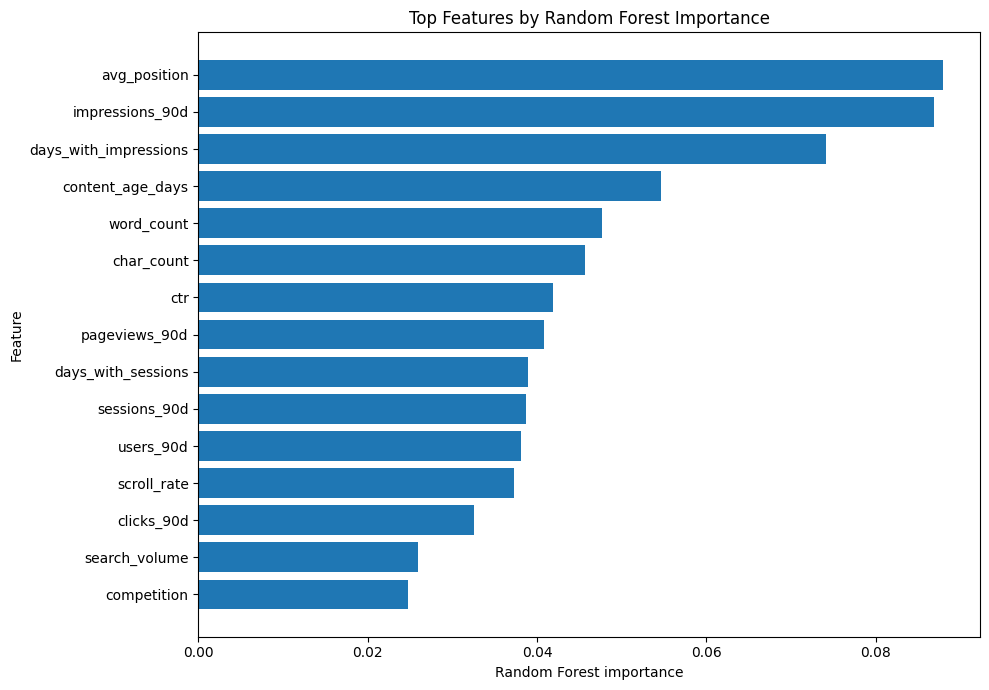

Saved: /content/work/figures/capstone_feature_importance.png


In [ ]:
# ============================================================
# FEATURE IMPORTANCE FIGURE
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_feature_importance["feature"][::-1],
    top_feature_importance["importance"][::-1]
)

plt.xlabel(
    "Random Forest importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Features by Random Forest Importance"
)

plt.tight_layout()

feature_importance_figure = (
    f"{FIGURE_DIR}/capstone_feature_importance.png"
)

plt.savefig(
    feature_importance_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    feature_importance_figure
)

### Freshness Analysis

As a complementary descriptive analysis, the dataset is grouped by the available `freshness_tier` field.

The analysis reports the observed share of records labelled as declining within each freshness group.

This comparison is descriptive only.

It does not establish that content age or freshness causes search-performance decline.

In [ ]:
# ============================================================
# FRESHNESS ANALYSIS
# ============================================================

if "freshness_tier" in df.columns:

    freshness_summary = (
        df.groupby(
            "freshness_tier",
            dropna=False
        )
        .agg(
            pages=("target", "size"),
            declining_pages=("target", "sum"),
            decline_rate=("target", "mean")
        )
        .reset_index()
        .sort_values(
            "decline_rate",
            ascending=False
        )
    )

    print(
        "Observed decline rate by freshness tier:"
    )

    display(
        freshness_summary.round(4)
    )

else:

    freshness_summary = pd.DataFrame()

    print(
        "freshness_tier unavailable in this dataset."
    )

Observed decline rate by freshness tier:


,freshness_tier,pages,declining_pages,decline_rate
3,91-180,9171,5604,0.6111
2,31-90,175,103,0.5886
0,0-30,20480,10473,0.5114
1,181+,174,82,0.4713


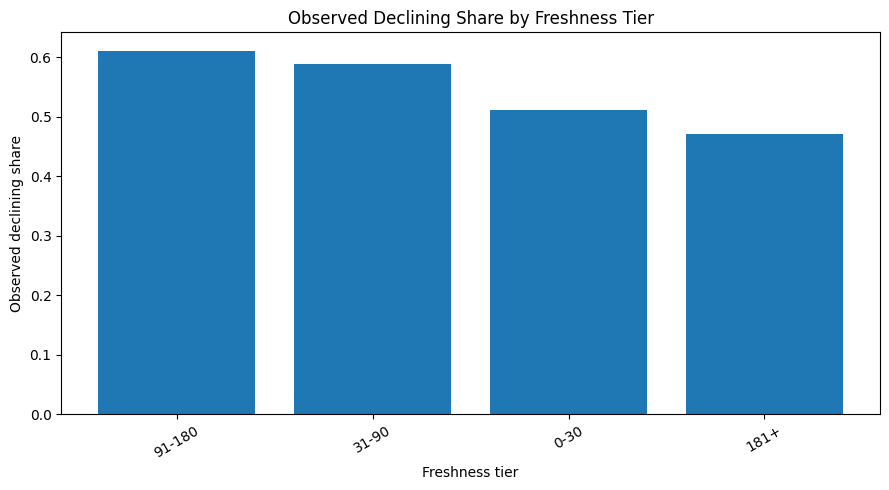

Saved: /content/work/figures/capstone_freshness_decline_rate.png


In [ ]:
# ============================================================
# FRESHNESS FIGURE
# ============================================================

if not freshness_summary.empty:

    plot_data = (
        freshness_summary
        .dropna(
            subset=["decline_rate"]
        )
        .copy()
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        plot_data[
            "freshness_tier"
        ].astype(str),
        plot_data[
            "decline_rate"
        ]
    )

    plt.ylabel(
        "Observed declining share"
    )

    plt.xlabel(
        "Freshness tier"
    )

    plt.title(
        "Observed Declining Share by Freshness Tier"
    )

    plt.xticks(
        rotation=30
    )

    plt.tight_layout()

    freshness_figure = (
        f"{FIGURE_DIR}/capstone_freshness_decline_rate.png"
    )

    plt.savefig(
        freshness_figure,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        freshness_figure
    )

else:

    freshness_figure = None

## 5. Limitations

This analysis is based on historical observational data. The model identifies patterns associated with an observed historical decline label, but it does not establish causation.

A high decline-risk score does not guarantee that a webpage will decline in the future. It also does not guarantee that refreshing the page will improve search performance.

The grouped-by-client validation provides a more conservative estimate of generalization to unseen clients than a simple random row split. However, the analysis is still based on an anonymized internship dataset rather than a live production system.

The model does not reveal Google's ranking algorithm. The results should not be presented as evidence that any feature is a Google ranking factor.

The appropriate language for interpreting the results is:

- observed
- measured
- associated with
- directional
- prioritization signal
- decision support

The analysis should avoid claims that the model:

- causes search-performance changes;
- guarantees future decline;
- guarantees that refreshing content will improve performance;
- proves a Google ranking factor;
- predicts future traffic with certainty.

### Monitoring and Retraining Considerations

If this approach were developed further, the following conditions would warrant re-evaluation.

**Performance drift**

Re-evaluate if grouped validation performance falls materially from the benchmark established in this notebook.

**Feature drift**

Monitor changes in the distributions of major model input features.

**Base-rate drift**

Monitor changes in the proportion of records labelled as declining.

**Queue stability**

Check whether the highest-priority records change substantially between consecutive runs without corresponding changes in the underlying data.

**Freshness drift**

Recheck the observed relationship between content freshness and decline when the underlying content mix changes.

**Retraining trigger**

Retrain and revalidate when substantial feature drift, base-rate drift, or sustained performance deterioration is observed.

### No-Go List

The model score alone should not be used to automatically:

- rewrite content;
- publish content;
- delete webpages;
- change titles;
- change metadata;
- make claims about Google ranking factors;
- treat the score as guaranteed future traffic loss;
- claim that refreshing a page will guarantee better search performance.

The system is therefore a prioritization aid for human review rather than an autonomous content-management system.

In [ ]:
# ============================================================
# SECTION 5 — LIMITATIONS, MONITORING & RETRAINING
# ============================================================

monitoring_triggers = {

    "Performance drift":
        "Re-evaluate if grouped validation performance falls materially from the current benchmark.",

    "Feature drift":
        "Monitor changes in the distributions of major model input features.",

    "Base-rate drift":
        "Monitor changes in the proportion of records labelled as declining.",

    "Queue stability":
        "Check whether the highest-priority records change substantially between consecutive runs without corresponding changes in the underlying data.",

    "Freshness drift":
        "Recheck the observed relationship between content freshness and decline when the underlying content mix changes.",

    "Retraining trigger":
        "Retrain and revalidate when substantial feature drift, base-rate drift, or sustained performance deterioration is observed."
}

print("SECTION 5 — LIMITATIONS")
print("=" * 60)

print("\nObservational-data limitation:")
print(
    "The model identifies patterns associated with an observed "
    "historical decline label but does not establish causation."
)

print("\nFuture-decline limitation:")
print(
    "A high decline-risk score does not guarantee future decline."
)

print("\nRefresh-impact limitation:")
print(
    "The model does not guarantee that refreshing content will "
    "improve search performance."
)

print("\nGoogle-ranking limitation:")
print(
    "The analysis does not identify or prove Google ranking factors."
)

print("\nMONITORING AND RETRAINING")
print("=" * 60)

for trigger, description in monitoring_triggers.items():
    print(f"\n{trigger}:")
    print(description)

print("\nNO-GO ACTIONS")
print("=" * 60)

no_go_actions = [
    "Automatic content rewriting",
    "Automatic publishing",
    "Automatic page deletion",
    "Automatic title changes",
    "Automatic metadata changes",
    "Claims about Google ranking factors",
    "Guaranteed future traffic-loss claims",
    "Guaranteed refresh-impact claims"
]

for action in no_go_actions:
    print("-", action)

print(
    "\nConclusion: The model is a human-review prioritization "
    "aid, not an autonomous content-management system."
)

SECTION 5 — LIMITATIONS

Observational-data limitation:
The model identifies patterns associated with an observed historical decline label but does not establish causation.

Future-decline limitation:
A high decline-risk score does not guarantee future decline.

Refresh-impact limitation:
The model does not guarantee that refreshing content will improve search performance.

Google-ranking limitation:
The analysis does not identify or prove Google ranking factors.

MONITORING AND RETRAINING

Performance drift:
Re-evaluate if grouped validation performance falls materially from the current benchmark.

Feature drift:
Monitor changes in the distributions of major model input features.

Base-rate drift:
Monitor changes in the proportion of records labelled as declining.

Queue stability:
Check whether the highest-priority records change substantially between consecutive runs without corresponding changes in the underlying data.

Freshness drift:
Recheck the observed relationship between con

## 6. Ranked Recommendations

After the grouped validation has been completed, a final Random Forest is trained on all available records using the same leakage-safe feature definition.

The final model is used to generate a decline-risk score for each record and convert those scores into a ranked editorial-review queue.

The score represents the model-estimated likelihood of belonging to the historically observed declining class.

The resulting ranking is a prioritization signal for human review. It is not an autonomous decision about what content should be changed.

### Final Model

The final Random Forest uses the same model configuration as the validated model:

- Random Forest classifier
- 200 trees
- random state = 42
- all available leakage-safe records used for fitting

This model is used to produce the action queue after validation has already been completed.

In [ ]:
# ============================================================
# FINAL MODEL FOR ACTION QUEUE
# ============================================================

rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_final.fit(
    X,
    y
)

print(
    "Final Random Forest trained on all available records."
)

print(
    "Training rows:",
    len(X)
)

print(
    "Number of features:",
    X.shape[1]
)

Final Random Forest trained on all available records.
Training rows: 30000
Number of features: 76


### Decline-Risk Scores

The final model produces a probability-like score for the historically observed declining class.

Higher scores indicate that the record is more strongly associated with the observed declining class under the fitted model.

These scores should be interpreted as prioritization signals rather than guaranteed future decline probabilities.

In [ ]:
 # ============================================================
# GENERATE DECLINE-RISK SCORES
# ============================================================

decline_class_index = list(
    rf_final.classes_
).index(1)

all_probabilities = (
    rf_final.predict_proba(X)
)

df["decline_risk_score"] = (
    all_probabilities[
        :,
        decline_class_index
    ]
)

print("Decline-risk scores generated.")

print(
    "Minimum:",
    round(
        df["decline_risk_score"].min(),
        3
    )
)

print(
    "Maximum:",
    round(
        df["decline_risk_score"].max(),
        3
    )
)

print(
    "Mean:",
    round(
        df["decline_risk_score"].mean(),
        3
    )
)

display(
    df[
        ["decline_risk_score"]
    ].head(10)
)

Decline-risk scores generated.
Minimum: 0.0
Maximum: 1.0
Mean: 0.541


,decline_risk_score
0,0.800
1,0.760
2,0.980
3,0.160
4,0.880
5,0.915
6,0.945
7,0.225
8,0.900
9,0.960


### Action Tiers

The decline-risk score is converted into four editorial-review tiers.

The tiers are designed to organize human review capacity rather than automate editorial decisions.

- **Priority review:** highest model-estimated decline risk
- **Review:** elevated decline-risk signal
- **Monitor:** moderate signal that may warrant continued observation
- **Lower priority:** comparatively lower signal

In [ ]:
 # ============================================================
# ACTION TIERS
# ============================================================

def assign_action_tier(score):

    if score >= 0.75:
        return "Priority review"

    elif score >= 0.60:
        return "Review"

    elif score >= 0.45:
        return "Monitor"

    else:
        return "Lower priority"


df["action_tier"] = (
    df["decline_risk_score"]
    .apply(assign_action_tier)
)

print("Action tiers created.")

tier_summary = (
    df["action_tier"]
    .value_counts()
    .rename_axis("action_tier")
    .reset_index(name="pages")
)

display(tier_summary)

Action tiers created.


,action_tier,pages
0,Priority review,15200
1,Lower priority,13738
2,Review,1054
3,Monitor,8


### Reason Codes

Reason codes provide simple human-readable context alongside the model score.

They are based on observable dataset fields and the model score.

The codes are intended to help a reviewer understand why a record may deserve attention. They should not be interpreted as causal explanations of search-performance decline.

In [ ]:
# ============================================================
# HUMAN-READABLE REASON CODES
# ============================================================

ctr_median = df["ctr"].median()

impressions_median = (
    df["impressions_90d"].median()
)


def build_reason_codes(row):

    reasons = []

    if row["decline_risk_score"] >= 0.75:
        reasons.append(
            "HIGH_DECLINE_RISK"
        )

    if row["days_since_last_update"] > 180:
        reasons.append(
            "CONTENT_FRESHNESS"
        )

    if row["ctr"] < ctr_median:
        reasons.append(
            "LOW_CTR"
        )

    if row["impressions_90d"] >= impressions_median:
        reasons.append(
            "MEANINGFUL_VISIBILITY"
        )

    if len(reasons) == 0:
        reasons.append(
            "MONITOR"
        )

    return "|".join(reasons)


df["reason_codes"] = (
    df.apply(
        build_reason_codes,
        axis=1
    )
)

print("Reason codes generated.")

display(
    df[
        [
            "decline_risk_score",
            "action_tier",
            "reason_codes"
        ]
    ].head(10)
)

Reason codes generated.


,decline_risk_score,action_tier,reason_codes
0,0.800,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
1,0.760,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY
2,0.980,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
3,0.160,Lower priority,MEANINGFUL_VISIBILITY
4,0.880,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
5,0.915,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY
6,0.945,Priority review,HIGH_DECLINE_RISK|LOW_CTR
7,0.225,Lower priority,LOW_CTR|MEANINGFUL_VISIBILITY
8,0.900,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
9,0.960,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY


### Recommended Editorial Actions

Each action tier is mapped to a human-review recommendation.

The recommendation tells the reviewer what level of attention is appropriate. It does not instruct the system to automatically modify or publish content.

In [ ]:
# ============================================================
# RECOMMENDED EDITORIAL ACTIONS
# ============================================================

action_map = {

    "Priority review":
        "Review content freshness, search intent, factual accuracy, and refresh opportunity first.",

    "Review":
        "Review the page for meaningful content or freshness improvements.",

    "Monitor":
        "Monitor performance and reassess if decline signals strengthen.",

    "Lower priority":
        "No immediate refresh recommendation; retain for monitoring."
}

df["recommended_action"] = (
    df["action_tier"]
    .map(action_map)
)

print(
    "Recommended editorial actions created."
)

display(
    df[
        [
            "decline_risk_score",
            "action_tier",
            "reason_codes",
            "recommended_action"
        ]
    ].head(10)
)

Recommended editorial actions created.


,decline_risk_score,action_tier,reason_codes,recommended_action
0,0.800,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."
1,0.760,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."
2,0.980,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."
3,0.160,Lower priority,MEANINGFUL_VISIBILITY,No immediate refresh recommendation; retain fo...
4,0.880,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."
5,0.915,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."
6,0.945,Priority review,HIGH_DECLINE_RISK|LOW_CTR,"Review content freshness, search intent, factu..."
7,0.225,Lower priority,LOW_CTR|MEANINGFUL_VISIBILITY,No immediate refresh recommendation; retain fo...
8,0.900,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."
9,0.960,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu..."


### Ranked Action Queue

The final output ranks all available records by decline-risk score from highest to lowest.

The queue is designed to help an SEO or content team decide which records should receive human review first when review capacity is limited.

The queue does not determine which pages must be changed. Human reviewers remain responsible for the final editorial decision.

In [ ]:
# ============================================================
# RANKED ACTION QUEUE
# ============================================================

queue = (
    df.sort_values(
        "decline_risk_score",
        ascending=False
    )
    .copy()
)

queue["priority_rank"] = (
    np.arange(len(queue)) + 1
)

optional_columns = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position"
]

queue_columns = [
    "priority_rank",
    "decline_risk_score",
    "action_tier",
    "reason_codes",
    "recommended_action"
]

queue_columns += [
    col
    for col in optional_columns
    if col in queue.columns
]

queue = queue[
    queue_columns
]

print(
    "Ranked action queue created."
)

print(
    "Number of rows:",
    len(queue)
)

print(
    "\nTop 20 records requiring review:"
)

display(
    queue.head(20)
)

Ranked action queue created.
Number of rows: 30000

Top 20 records requiring review:


,priority_rank,decline_risk_score,action_tier,reason_codes,recommended_action,content_age_days,days_since_last_update,impressions_90d,ctr,avg_position
3941,1,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",141,20,41078,0.09,22.2
11939,2,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",224,20,6984,0.24,16.2
22484,3,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",309,104,886,0.11,26.9
4816,4,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR,"Review content freshness, search intent, factu...",169,20,332,0.00,7.7
29829,5,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",224,20,8816,0.56,16.4
24717,6,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",147,20,4059,0.05,20.0
9680,7,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",141,20,5628,0.04,36.7
17547,8,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR,"Review content freshness, search intent, factu...",124,104,337,0.00,1.8
24163,9,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR,"Review content freshness, search intent, factu...",169,20,342,0.00,26.0
29428,10,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, factu...",225,20,4488,0.18,14.7


 ## 7. Artifacts the Paper Embeds

The following artifacts are generated from the actual notebook run.

These outputs allow the deployed research paper to use the same results produced by the capstone analysis.

The exported artifacts include:

- ranked action queue;
- freshness summary;
- model-versus-baseline results;
- feature importance;
- confusion matrix;
- metrics receipt.

### Export Ranked Action Queue

The ranked action queue generated in Section 6 is exported as a CSV file for use by the research paper and for reproducibility.

In [ ]:
# ============================================================
# EXPORT RANKED ACTION QUEUE
# ============================================================

queue_path = (
    f"{OUTPUT_DIR}/capstone_ranked_action_queue.csv"
)

queue.to_csv(
    queue_path,
    index=False
)

print(
    "Ranked action queue saved:"
)

print(queue_path)

print(
    "\nRows exported:",
    len(queue)
)

Ranked action queue saved:
/content/work/outputs/capstone_ranked_action_queue.csv

Rows exported: 30000


### Export Freshness Summary

The observed freshness analysis from Section 4 is exported so that the deployed paper can reproduce the same descriptive freshness results.

In [ ]:
# ============================================================
# EXPORT FRESHNESS SUMMARY
# ============================================================

freshness_path = (
    f"{OUTPUT_DIR}/capstone_freshness_summary.csv"
)

if not freshness_summary.empty:

    freshness_summary.to_csv(
        freshness_path,
        index=False
    )

    print(
        "Freshness summary saved:"
    )

    print(freshness_path)

else:

    print(
        "No freshness summary available."
    )

Freshness summary saved:
/content/work/outputs/capstone_freshness_summary.csv


### Export Model-vs-Baseline Results

The comparison table from Section 4 is exported as a CSV file.

It contains the same accuracy, precision, recall, and F1 results used in the notebook.

In [ ]:
# ============================================================
# EXPORT MODEL VS BASELINE RESULTS
# ============================================================

results_path = (
    f"{OUTPUT_DIR}/capstone_model_vs_baseline.csv"
)

results.to_csv(
    results_path,
    index=False
)

print(
    "Model-vs-baseline results saved:"
)

print(results_path)

display(
    results.round(4)
)

Model-vs-baseline results saved:
/content/work/outputs/capstone_model_vs_baseline.csv


,Metric,Rule-based baseline,Random Forest,RF - Baseline
0,Accuracy,0.489,0.5723,0.0832
1,Precision,0.000,0.5766,0.5766
2,Recall,0.000,0.6132,0.6132
3,F1,0.000,0.5943,0.5943


### Export Feature Importance

The Random Forest feature-importance table generated during Section 4 is exported for use in the research paper.

Feature importance is presented as a model interpretation aid and not as evidence of causation or a Google ranking factor.

In [ ]:
# ============================================================
# EXPORT FEATURE IMPORTANCE
# ============================================================

feature_importance_path = (
    f"{OUTPUT_DIR}/capstone_feature_importance.csv"
)

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print(
    "Feature importance saved:"
)

print(feature_importance_path)

display(
    feature_importance.head(15)
)

Feature importance saved:
/content/work/outputs/capstone_feature_importance.csv


,feature,importance
19,avg_position,0.087944
5,impressions_90d,0.086929
13,days_with_impressions,0.074105
15,content_age_days,0.054649
3,word_count,0.047660
4,char_count,0.045690
18,ctr,0.041840
7,pageviews_90d,0.040858
14,days_with_sessions,0.038911
8,sessions_90d,0.038757


### Export Confusion Matrix

The Random Forest confusion matrix generated during Section 4 is exported as a CSV file.

This preserves the exact classification results from the grouped-by-client test split.

In [ ]:
# ============================================================
# EXPORT CONFUSION MATRIX
# ============================================================

confusion_path = (
    f"{OUTPUT_DIR}/capstone_confusion_matrix.csv"
)

cm_df.to_csv(
    confusion_path,
    index=True
)

print(
    "Confusion matrix saved:"
)

print(confusion_path)

display(
    cm_df
)

Confusion matrix saved:
/content/work/outputs/capstone_confusion_matrix.csv


,Predicted non-declining,Predicted declining
Actual non-declining,1596,1418
Actual declining,1218,1931


### Export Metrics Receipt

A metrics receipt is generated to preserve the main experimental configuration and results.

The receipt records the dataset size, feature count, grouped validation design, model configuration, baseline metrics, Random Forest metrics, and leakage-control checks.

In [ ]:
# ============================================================
# EXPORT METRICS RECEIPT
# ============================================================

metrics_receipt = {

    "validation":
        "grouped_by_client",

    "random_state":
        RANDOM_STATE,

    "dataset_rows":
        int(len(df)),

    "feature_count":
        int(X.shape[1]),

    "training_rows":
        int(len(X_train)),

    "testing_rows":
        int(len(X_test)),

    "training_clients":
        int(groups_train.nunique()),

    "testing_clients":
        int(groups_test.nunique()),

    "declining_base_rate":
        float(declining_base_rate),

    "baseline": {

        "accuracy":
            float(baseline_accuracy),

        "precision":
            float(baseline_precision),

        "recall":
            float(baseline_recall),

        "f1":
            float(baseline_f1)
    },

    "random_forest": {

        "accuracy":
            float(group_accuracy),

        "precision":
            float(group_precision),

        "recall":
            float(group_recall),

        "f1":
            float(group_f1)
    },

    "model": {

        "type":
            "RandomForestClassifier",

        "n_estimators":
            200,

        "random_state":
            RANDOM_STATE
    },

    "leakage_control": {

        "target_excluded":
            True,

        "trend_direction_excluded":
            True,

        "trend_pct_excluded":
            True,

        "recent_performance_fields_excluded":
            True,

        "identifiers_excluded":
            True
    }
}

metrics_path = (
    f"{OUTPUT_DIR}/capstone_metrics_receipt.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

print(
    "Metrics receipt saved:"
)

print(metrics_path)

print("\nMetrics receipt:")
print(
    json.dumps(
        metrics_receipt,
        indent=2
    )
)


Metrics receipt saved:
/content/work/outputs/capstone_metrics_receipt.json

Metrics receipt:
{
  "validation": "grouped_by_client",
  "random_state": 42,
  "dataset_rows": 30000,
  "feature_count": 76,
  "training_rows": 23837,
  "testing_rows": 6163,
  "training_clients": 25,
  "testing_clients": 7,
  "declining_base_rate": 0.5420666666666667,
  "baseline": {
    "accuracy": 0.48904754178159987,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0
  },
  "random_forest": {
    "accuracy": 0.5722862242414408,
    "precision": 0.5765900268736937,
    "recall": 0.6132105430295332,
    "f1": 0.5943367189904586
  },
  "model": {
    "type": "RandomForestClassifier",
    "n_estimators": 200,
    "random_state": 42
  },
  "leakage_control": {
    "target_excluded": true,
    "trend_direction_excluded": true,
    "trend_pct_excluded": true,
    "recent_performance_fields_excluded": true,
    "identifiers_excluded": true
  }
}


In [ ]:
print("FINAL CAPSTONE CHECK")
print("=" * 60)

checks = {
    "Dataset rows = 30,000": len(df) == 30000,
    "Target exists": "target" in df.columns,
    "Target excluded from X": "target" not in X.columns,
    "No client overlap": set(groups_train.unique()).isdisjoint(set(groups_test.unique())),
    "Train/test dimensions match": len(X_train) == len(y_train) and len(X_test) == len(y_test),
    "RF trained": hasattr(rf_group, "predict"),
    "Final model trained": hasattr(rf_final, "predict_proba"),
    "Decline scores generated": "decline_risk_score" in df.columns,
    "Action tiers generated": "action_tier" in df.columns,
    "Reason codes generated": "reason_codes" in df.columns,
    "Recommended actions generated": "recommended_action" in df.columns,
    "Ranked queue generated": len(queue) == len(df),
    "Metrics receipt generated": os.path.exists(metrics_path),
    "Queue export generated": os.path.exists(queue_path),
    "Freshness export generated": os.path.exists(freshness_path),
    "Results export generated": os.path.exists(results_path),
    "Feature importance export generated": os.path.exists(feature_importance_path),
    "Confusion matrix export generated": os.path.exists(confusion_path),
}

for name, passed in checks.items():
    print(("PASS" if passed else "FAIL") + " — " + name)

print("=" * 60)

if all(checks.values()):
    print("ALL AUTOMATED CAPSTONE CHECKS PASSED.")
else:
    print("SOME CHECKS FAILED — DO NOT COMMIT YET.")

FINAL CAPSTONE CHECK
PASS — Dataset rows = 30,000
PASS — Target exists
PASS — Target excluded from X
PASS — No client overlap
PASS — Train/test dimensions match
PASS — RF trained
PASS — Final model trained
PASS — Decline scores generated
PASS — Action tiers generated
PASS — Reason codes generated
PASS — Recommended actions generated
PASS — Ranked queue generated
PASS — Metrics receipt generated
PASS — Queue export generated
PASS — Freshness export generated
PASS — Results export generated
PASS — Feature importance export generated
PASS — Confusion matrix export generated
ALL AUTOMATED CAPSTONE CHECKS PASSED.


# 5-Minute Demo & Shareable Story

## 5-Minute Demo Outline

### 1. Question — ~45 seconds

**Problem**

Search-performance changes can make it difficult to determine which content deserves attention first. A large content set may contain pages that are declining, recovering, or showing other signals that make them worth reviewing, but manually inspecting every page is inefficient.

**Research Question**

> How can machine learning support the prioritization of webpages for content review or refresh based on observed search-performance trends?

This project follows the **Content Refresh Prioritization** lane.

The objective is not to explain or prove Google's ranking algorithm. Instead, the project builds a repeatable machine-learning workflow that can help analysts identify higher-priority content opportunities for human review.

---

## 2. Method — ~1 minute

The workflow begins with inspection of the FlyRank ML Internship dataset and understanding the available search-performance information.

The modeling process then follows these stages:

1. Dataset inspection and preparation
2. Feature selection
3. Target definition
4. Leakage identification and exclusion
5. Baseline construction
6. Machine-learning model training
7. Evaluation using the same evaluation framework as the baseline
8. Error analysis
9. Feature-importance analysis
10. Conversion of predictions into ranked content opportunities

The target represents **observed search-performance trend direction**.

An important part of the methodology is leakage control. Information that could reveal the target directly or would not realistically be available at the intended decision point should not be used as a predictive feature.

The baseline provides a reference point for evaluating whether the trained model provides additional predictive value. The final output is not simply a classification result; it is converted into a prioritization workflow that can support content-review decisions.

---

## 3. One Chart — ~1 minute

The main visual I would present during the demo is the final model evaluation and error-analysis output.

The evaluation results show how the trained model behaves on held-out evaluation data. The confusion matrix provides an intuitive way to explain where predictions agree with the observed trend labels and where the model makes mistakes.

Rather than presenting only one performance number, the evaluation should be interpreted together with the model's error patterns and feature-importance results.

This is important because a model can have a useful overall score while still performing differently across classes or types of observations.

**Demo talking point:**

> "This chart is useful because it lets us see not only whether the model makes predictions, but also where those predictions are correct and where the model needs to be treated cautiously."

---

## 4. One Honest Result — ~1 minute

The main result is that the machine-learning workflow can transform observed search-performance signals into a ranked set of content opportunities for review.

The model therefore provides a practical prioritization mechanism:

**Observed signals → Model prediction → Priority ranking → Human review**

The result should be interpreted as **directional decision support**, not as a guarantee that refreshing a page will improve its future search performance.

The model identifies patterns present in the available data. Those patterns do not establish that a particular feature causes changes in Google rankings, and the analysis does not claim to reverse-engineer or prove Google's ranking algorithm.

The most useful outcome is therefore the ability to make the review process more systematic and repeatable.

---

## 5. One Recommendation — ~1 minute

The recommended operational workflow is:

> **Prioritize → Inspect → Review → Act → Monitor**

### Prioritize

Begin with the highest-ranked content opportunities produced by the model.

### Inspect

Review the supporting signals behind each recommendation instead of relying only on the model score.

### Review

A human analyst should determine whether the page actually needs a refresh, improvement, monitoring, or no action.

### Act

Apply an appropriate content action only after human review.

### Monitor

Continue observing future search-performance data to determine whether the content behaves differently over time.

The model should therefore be treated as a **decision-support layer**, not an automatic content-editing system.

---

# Shareable Cut 1 — Short Social Post

I built a machine-learning workflow for **Content Refresh Prioritization** as part of my FlyRank Machine Learning capstone.

The project explores how observed search-performance signals can be used to rank content opportunities that may deserve human review or refresh.

The workflow covers dataset inspection, feature selection, leakage control, baseline comparison, model evaluation, error analysis, feature importance, and ranked recommendations.

The key lesson was that machine learning can help answer **"what should we review first?"** without pretending to prove why Google rankings change.

The final system is therefore framed as a **decision-support workflow**, not a causal SEO model or a guarantee of future ranking performance.

---

# Shareable Cut 2 — Employer-Facing Summary

## What I Built

I built a machine-learning **Content Refresh Prioritization** workflow that uses observed search-performance trends to rank webpages according to their potential review priority.

The workflow combines data preparation, feature engineering, leakage checks, baseline comparison, machine-learning modeling, evaluation, error analysis, and feature-importance analysis before converting predictions into ranked content recommendations.

## What Data I Used

The project was built using the **FlyRank ML Internship dataset**, using search and content-performance information required for the modeling task.

The published work follows the project's public-safety requirements by avoiding client-identifying information, private queries, credentials, raw exports, and other sensitive information.

## What It Showed

The project demonstrates how machine learning can support a repeatable content-prioritization workflow.

Instead of treating every page equally, the model can be used to identify higher-priority opportunities that analysts can inspect first.

The results are intentionally framed as **directional decision support**. Feature importance and model predictions describe patterns captured by the trained model; they do not prove causal relationships or explain Google's ranking algorithm.

## Practical Takeaway

The workflow provides a structured process for moving from:

**Search-performance data → Predictive signals → Ranked opportunities → Human review → Content action → Monitoring**

This makes the model useful as an analytical prioritization tool while keeping the final decision with a human reviewer.

---

# Closing Statement

This capstone demonstrates a practical machine-learning approach to **Content Refresh Prioritization**: using real search-performance data to make content review more systematic while maintaining leakage controls, honest evaluation, and responsible interpretation.

The central principle is simple:

> **Use ML to prioritize attention, not to replace judgment.**

## Final Self-Check

Before submission, confirm each line honestly:

- [ ] Section 1 — Research question and decision supported are documented.
- [ ] Section 2 — Actual FlyRank dataset, dataset size, target, exclusions, leakage risks, and public-safety restrictions are documented.
- [ ] Section 3 — Methodology, grouped-by-client validation, validation checks, baseline, Random Forest, and leakage controls are documented.
- [ ] Section 4 — Baseline metrics and Random Forest metrics are reported on the same grouped test split.
- [ ] Section 4 — Honest model-vs-baseline comparison table is included.
- [ ] Section 4 — Model-vs-baseline chart is generated.
- [ ] Section 4 — Confusion matrix is generated.
- [ ] Section 4 — Feature importance is generated and interpreted carefully.
- [ ] Section 4 — Freshness analysis is generated as descriptive analysis.
- [ ] Section 5 — Limitations and honest framing are documented.
- [ ] Section 5 — Monitoring and retraining considerations are documented.
- [ ] Section 6 — Final model is trained after validation.
- [ ] Section 6 — Decline-risk scores are generated.
- [ ] Section 6 — Action tiers are generated.
- [ ] Section 6 — Human-readable reason codes are generated.
- [ ] Section 6 — Recommended editorial actions are generated.
- [ ] Section 6 — Ranked action queue is generated.
- [ ] Section 7 — Ranked action queue is exported.
- [ ] Section 7 — Freshness summary is exported.
- [ ] Section 7 — Results table is exported.
- [ ] Section 7 — Feature importance is exported.
- [ ] Section 7 — Confusion matrix is exported.
- [ ] Section 7 — Metrics receipt is exported.
- [ ] The notebook runs from top to bottom without errors.
- [ ] No client names are included.
- [ ] No private URLs, queries, domains, or credentials are included.
- [ ] No claims are made that the model proves a Google ranking factor.
- [ ] No causal claims are made about content refresh success.
- [ ] Claims use careful language such as observed, measured, associated, directional, and decision-support.
- [ ] The notebook is saved as `work/notebooks/capstone.ipynb`.
- [ ] The research paper is deployed.
- [ ] The deployed paper URL is saved in `submission/paper_url.txt`.
- [ ] `submission/paper_url.txt` contains exactly one URL line.
- [ ] The GitHub repository URL is ready for submission.